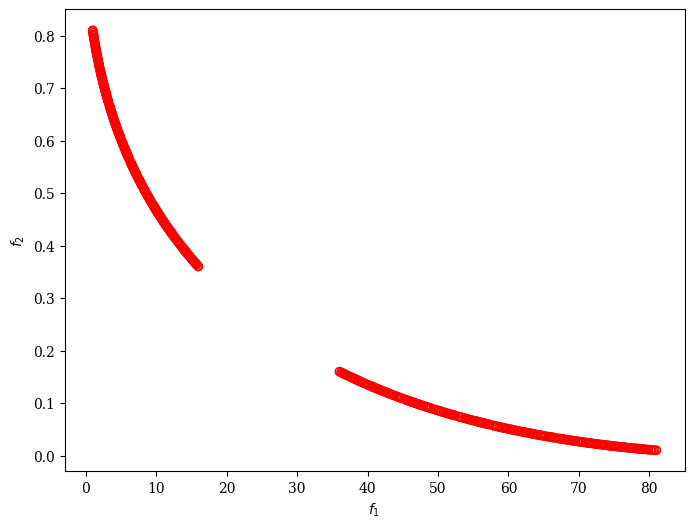

In [3]:
import numpy as np
 
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import ElementwiseProblem
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter
 
 
class MyProblem(ElementwiseProblem):
 
    def __init__(self):
        super().__init__(n_var=2,
                         n_obj=2,
                         n_ieq_constr=2,
                         xl=np.array([-2, -2]),
                         xu=np.array([2, 2]))
 
    def _evaluate(self, x, out, *args, **kwargs):
        f1 = 100 * (x[0] ** 2 + x[1] ** 2)
        f2 = (x[0] - 1) ** 2 + x[1] ** 2
 
        g1 = 2 * (x[0] - 0.1) * (x[0] - 0.9) / 0.18
        g2 = - 20 * (x[0] - 0.4) * (x[0] - 0.6) / 4.8
 
        out["F"] = [f1, f2]
        out["G"] = [g1, g2]
 
 
problem = MyProblem()
 
algorithm = NSGA2(pop_size=500)
 
res = minimize(problem,
               algorithm,
               ("n_gen", 100),
               verbose=False,
               seed=1)
 
plot = Scatter()
plot.add(res.F, edgecolor="red", facecolor="none")
plot.show()

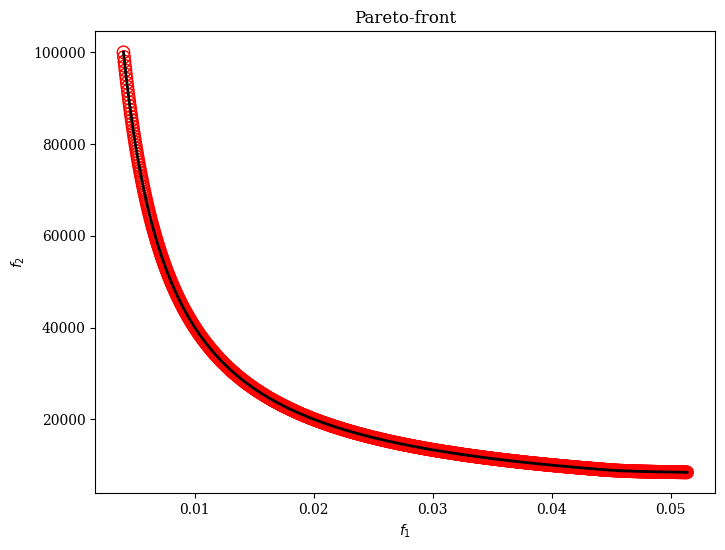

In [4]:
from pymoo.problems import get_problem
from pymoo.visualization.scatter import Scatter
 
pf = get_problem("truss2d").pareto_front()
 
sc = Scatter(title="Pareto-front")
sc.add(pf, s=80, facecolors='none', edgecolors='r')
sc.add(pf, plot_type="line", color="black", linewidth=2)
sc.show()